## 2. XGBoost

In [1]:
# imports

import numpy as np
import pandas as pd

from itertools import permutations, product
from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
from tqdm.notebook import tqdm

In [2]:
df_p1 = pd.read_json("data/raw_static/ARMAS_STATIC_20132023_P1.json", lines=True)
df_p2 = pd.read_json("data/raw_static/ARMAS_STATIC_20132023_P2.json", lines=True)
df_p3 = pd.read_json("data/raw_static/ARMAS_STATIC_20132023_P3.json", lines=True)

df_p1["partition"] = "P1"
df_p2["partition"] = "P2"
df_p3["partition"] = "P3"

df = pd.concat([df_p1, df_p2, df_p3], ignore_index=True)

print(df.shape)
print(df["partition"].value_counts())

(92476, 49)
partition
P1    32380
P2    30787
P3    29309
Name: count, dtype: int64


In [3]:
# target and selected features

target_col = "ARMAS"

drop_cols = [
    "ARMAS",
    "NAIRASV2",
    "NAIRASV3",
    "Datetime",
    "Vehicle_ID",
    "partition"
]

feature_cols = [
    col for col in df.columns
    if col not in drop_cols
]

print("Number of features:", len(feature_cols))
print(feature_cols)

Number of features: 43
['Latitude', 'Longitude', 'Altitude(Bar)', 'Altitude(GPS)', 'Geomagnetic_latitude', 'Geomagnetic_longitude', 'Geomagnetic_Rc', 'Geomagnetic_Lshell', 'NM_NEWK', 'NM_OULU', 'NM_THUL', 'NM_SOPO', 'SXR_short', 'SXR_long', 'Particles_P1', 'Particles_P5', 'Particles_P10', 'Particles_P30', 'Particles_P50', 'Particles_P100', 'Particles_E20', 'SW_B', 'SW_Bx', 'SW_By', 'SW_Bz', 'SW_V', 'SW_Vx', 'SW_Vy', 'SW_Vz', 'SW_density', 'SW_temperature', 'SW_pressure', 'Index_Kp', 'Index_Dst', 'Index_Ap', 'Solar_sunspots', 'Solar_f107', 'Solar_NPF', 'Solar_SPF', 'Solar_APF', 'Solar_NPF20', 'Solar_SPF20', 'Solar_APF20']


In [4]:
# 6 rotations, as developed by Sadykov et al. (2026)

splits = list(permutations(["P1", "P2", "P3"], 3))

for split in splits:
    split_name = f"{split[0][-1]}{split[1][-1]}{split[2][-1]}"
    print(split_name, "Train:", split[0], "Val:", split[1], "Test:", split[2])

123 Train: P1 Val: P2 Test: P3
132 Train: P1 Val: P3 Test: P2
213 Train: P2 Val: P1 Test: P3
231 Train: P2 Val: P3 Test: P1
312 Train: P3 Val: P1 Test: P2
321 Train: P3 Val: P2 Test: P1


In [5]:
# function evaluation metrics

def evaluate_regression(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    if len(y_true) > 1 and np.std(y_true) > 0 and np.std(y_pred) > 0:
        pearson = pearsonr(y_true, y_pred)[0]
        r2 = r2_score(y_true, y_pred)
    else:
        pearson = np.nan
        r2 = np.nan

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2,
        "Pearson_r": pearson,
        "Bias": np.mean(y_pred - y_true),
        "Underestimation_%": np.mean(y_pred < y_true) * 100
    }

In [6]:
# grid as developed by Sanjib et al. (2025)

xgb_param_grid = {
    "n_estimators": [50, 100, 300],
    "max_depth": [3, 6, 10],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 1.0],
    "reg_alpha": [0, 0.1],
    "reg_lambda": [1, 5, 10],
}

param_names = list(xgb_param_grid.keys())
param_combinations = list(product(*xgb_param_grid.values()))

print("Number of hyperparameter combinations:", len(param_combinations))
print("Total fits across 6 rotations:", len(param_combinations) * len(splits))

Number of hyperparameter combinations: 972
Total fits across 6 rotations: 5832


In [7]:
# grid search & evalutaion & save predictions

xgb_results = []
xgb_best_params_by_split = []
xgb_predictions_all = []

for train_p, val_p, test_p in tqdm(splits, desc="XGBoost rotations"):

    split_name = f"{train_p[-1]}{val_p[-1]}{test_p[-1]}"

    train_df = df[df["partition"] == train_p].copy()
    val_df   = df[df["partition"] == val_p].copy()
    test_df  = df[df["partition"] == test_p].copy()

    X_train = train_df[feature_cols]
    y_train = train_df[target_col]

    X_val = val_df[feature_cols]
    y_val = val_df[target_col]

    X_test = test_df[feature_cols]
    y_test = test_df[target_col]

    best_rmse = np.inf
    best_model = None
    best_params = None

    for values in tqdm(param_combinations, desc=f"Grid {split_name}", leave=False):
        params = dict(zip(param_names, values))

        model = XGBRegressor(
            **params,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1,
            tree_method="hist"
        )

        model.fit(X_train, y_train)

        y_val_pred = model.predict(X_val)
        val_metrics = evaluate_regression(y_val, y_val_pred)

        if val_metrics["RMSE"] < best_rmse:
            best_rmse = val_metrics["RMSE"]
            best_model = model
            best_params = params

    y_train_pred = best_model.predict(X_train)
    y_val_pred   = best_model.predict(X_val)
    y_test_pred  = best_model.predict(X_test)

    train_metrics = evaluate_regression(y_train, y_train_pred)
    val_metrics   = evaluate_regression(y_val, y_val_pred)
    test_metrics  = evaluate_regression(y_test, y_test_pred)

    xgb_results.append({
        "Model": "XGBoost",
        "Split": split_name,
        "Train_partition": train_p,
        "Validation_partition": val_p,
        "Test_partition": test_p,

        "Train_RMSE": train_metrics["RMSE"],
        "Train_MAE": train_metrics["MAE"],
        "Train_R2": train_metrics["R2"],
        "Train_Pearson_r": train_metrics["Pearson_r"],
        "Train_Bias": train_metrics["Bias"],
        "Train_Underestimation_%": train_metrics["Underestimation_%"],

        "Validation_RMSE": val_metrics["RMSE"],
        "Validation_MAE": val_metrics["MAE"],
        "Validation_R2": val_metrics["R2"],
        "Validation_Pearson_r": val_metrics["Pearson_r"],
        "Validation_Bias": val_metrics["Bias"],
        "Validation_Underestimation_%": val_metrics["Underestimation_%"],

        "Test_RMSE": test_metrics["RMSE"],
        "Test_MAE": test_metrics["MAE"],
        "Test_R2": test_metrics["R2"],
        "Test_Pearson_r": test_metrics["Pearson_r"],
        "Test_Bias": test_metrics["Bias"],
        "Test_Underestimation_%": test_metrics["Underestimation_%"],
    })

    xgb_best_params_by_split.append({
        "Split": split_name,
        **best_params,
        "Best_Validation_RMSE": best_rmse
    })

    pred_df = pd.DataFrame({
        "Model": "XGBoost",
        "Split": split_name,
        "Train_partition": train_p,
        "Validation_partition": val_p,
        "Test_partition": test_p,
        "y_true": y_test.values,
        "y_pred": y_test_pred
    })

    pred_df["residual"] = pred_df["y_pred"] - pred_df["y_true"]
    pred_df["abs_error"] = np.abs(pred_df["residual"])
    pred_df["sq_error"] = pred_df["residual"] ** 2
    pred_df["underpred"] = pred_df["y_pred"] < pred_df["y_true"]

    pred_df["tail_ge_15"] = pred_df["y_true"] >= 15
    pred_df["tail_ge_20"] = pred_df["y_true"] >= 20
    pred_df["pred_ge_15"] = pred_df["y_pred"] >= 15
    pred_df["pred_ge_20"] = pred_df["y_pred"] >= 20

    xgb_predictions_all.append(pred_df)

    pd.DataFrame(xgb_results).to_csv("xgb_results_progress.csv", index=False)
    pd.DataFrame(xgb_best_params_by_split).to_csv("xgb_best_params_progress.csv", index=False)
    pd.concat(xgb_predictions_all, ignore_index=True).to_csv("xgb_predictions_progress.csv", index=False)

XGBoost rotations:   0%|          | 0/6 [00:00<?, ?it/s]

Grid 123:   0%|          | 0/972 [00:00<?, ?it/s]

Grid 132:   0%|          | 0/972 [00:00<?, ?it/s]

Grid 213:   0%|          | 0/972 [00:00<?, ?it/s]

Grid 231:   0%|          | 0/972 [00:00<?, ?it/s]

Grid 312:   0%|          | 0/972 [00:00<?, ?it/s]

Grid 321:   0%|          | 0/972 [00:00<?, ?it/s]

In [8]:
xgb_results = pd.DataFrame(xgb_results)
xgb_best_params_by_split = pd.DataFrame(xgb_best_params_by_split)
xgb_predictions_all = pd.concat(xgb_predictions_all, ignore_index=True)

xgb_results.to_csv("xgb_results_final.csv", index=False)
xgb_best_params_by_split.to_csv("xgb_best_params_final.csv", index=False)
xgb_predictions_all.to_csv("xgb_predictions_all.csv", index=False)

display(xgb_results)
display(xgb_best_params_by_split)
display(xgb_predictions_all.head())

,Model,Split,Train_partition,Validation_partition,Test_partition,Train_RMSE,Train_MAE,Train_R2,Train_Pearson_r,Train_Bias,...,Validation_R2,Validation_Pearson_r,Validation_Bias,Validation_Underestimation_%,Test_RMSE,Test_MAE,Test_R2,Test_Pearson_r,Test_Bias,Test_Underestimation_%
0,XGBoost,123,P1,P2,P3,3.226982,2.385886,0.630942,0.795938,-0.002269,...,0.532701,0.733478,-0.116433,44.388865,3.722565,2.759344,0.520667,0.722405,-0.119208,44.856529
1,XGBoost,132,P1,P3,P2,3.238169,2.389727,0.628379,0.794002,-0.001018,...,0.525456,0.725329,-0.124209,46.531782,3.737923,2.705146,0.521595,0.726227,-0.166494,46.016176
2,XGBoost,213,P2,P1,P3,3.280498,2.376503,0.631520,0.796027,0.001473,...,0.521341,0.722278,-0.095433,46.423718,3.653974,2.699703,0.538168,0.734627,-0.128848,44.945239
3,XGBoost,231,P2,P3,P1,3.287410,2.379187,0.629965,0.794749,0.004303,...,0.540323,0.736035,-0.163192,45.723157,3.703804,2.705149,0.513819,0.717274,-0.122338,47.090797
4,XGBoost,312,P3,P1,P2,3.225903,2.378634,0.640039,0.801392,-0.000885,...,0.539528,0.734809,-0.009552,44.749846,3.655646,2.674478,0.542424,0.739579,-0.040016,43.414428
5,XGBoost,321,P3,P2,P1,3.215255,2.375096,0.642411,0.802920,0.001597,...,0.542694,0.739254,-0.015563,42.751811,3.619356,2.675276,0.535737,0.731994,0.033704,44.234095


,Split,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,reg_alpha,reg_lambda,Best_Validation_RMSE
0,123,100,3,0.1,0.8,1.0,0.0,1,3.694280
1,132,50,3,0.2,1.0,1.0,0.1,10,3.703920
2,213,100,3,0.1,0.8,1.0,0.0,1,3.675041
3,231,100,3,0.1,0.6,1.0,0.1,10,3.645440
4,312,100,3,0.1,1.0,0.6,0.0,10,3.604549
5,321,100,3,0.1,0.6,0.6,0.0,1,3.654567


,Model,Split,Train_partition,Validation_partition,Test_partition,y_true,y_pred,residual,abs_error,sq_error,underpred,tail_ge_15,tail_ge_20,pred_ge_15,pred_ge_20
0,XGBoost,123,P1,P2,P3,8.584,8.285419,-0.298581,0.298581,0.089151,True,False,False,False,False
1,XGBoost,123,P1,P2,P3,8.584,8.285419,-0.298581,0.298581,0.089151,True,False,False,False,False
2,XGBoost,123,P1,P2,P3,12.876,8.629397,-4.246603,4.246603,18.033634,True,False,False,False,False
3,XGBoost,123,P1,P2,P3,8.584,6.413508,-2.170492,2.170492,4.711036,True,False,False,False,False
4,XGBoost,123,P1,P2,P3,8.584,6.413508,-2.170492,2.170492,4.711036,True,False,False,False,False


In [9]:
summary_cols = [
    "Train_RMSE", "Train_R2",
    "Validation_RMSE", "Validation_R2",
    "Test_RMSE", "Test_R2",
    "Test_MAE", "Test_Pearson_r",
    "Test_Bias", "Test_Underestimation_%"
]

xgb_summary = xgb_results[summary_cols].agg(["mean", "std"])
xgb_summary.to_csv("xgb_summary_mean_std.csv")

xgb_summary

,Train_RMSE,Train_R2,Validation_RMSE,Validation_R2,Test_RMSE,Test_R2,Test_MAE,Test_Pearson_r,Test_Bias,Test_Underestimation_%
mean,3.245703,0.633876,3.662966,0.533674,3.682211,0.528735,2.703183,0.728684,-0.090533,45.092877
std,0.030583,0.005840,0.036315,0.008723,0.046157,0.011523,0.030908,0.008254,0.073564,1.302038


In [10]:
# sanity check 

print("Rows in df:", len(df))
print("Rows in xgb_predictions_all:", len(xgb_predictions_all))

print("\nRows per partition in df:")
print(df["partition"].value_counts())

print("\nRows per test partition in predictions:")
print(xgb_predictions_all["Test_partition"].value_counts())

print("\nRows per split:")
print(xgb_predictions_all["Split"].value_counts().sort_index())

Rows in df: 92476
Rows in xgb_predictions_all: 184952

Rows per partition in df:
partition
P1    32380
P2    30787
P3    29309
Name: count, dtype: int64

Rows per test partition in predictions:
Test_partition
P1    64760
P2    61574
P3    58618
Name: count, dtype: int64

Rows per split:
Split
123    29309
132    30787
213    29309
231    32380
312    30787
321    32380
Name: count, dtype: int64


In [11]:
# helper function 

def regression_metrics_subset(df_subset):
    y_true = df_subset["y_true"].values
    y_pred = df_subset["y_pred"].values

    out = {
        "n": len(df_subset),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "Bias": np.mean(y_pred - y_true),
        "Underestimation_%": np.mean(y_pred < y_true) * 100,
        "Median_AE": np.median(np.abs(y_pred - y_true)),
    }

    if len(df_subset) > 1 and np.std(y_true) > 0 and np.std(y_pred) > 0:
        out["R2"] = r2_score(y_true, y_pred)
        out["Pearson_r"] = pearsonr(y_true, y_pred)[0]
    else:
        out["R2"] = np.nan
        out["Pearson_r"] = np.nan

    return pd.Series(out)

In [12]:
# reconstruct metrics per split

xgb_overall_by_split = (
    xgb_predictions_all
    .groupby("Split")
    .apply(regression_metrics_subset)
    .reset_index()
)

xgb_overall_by_split

C:\Users\lenaj\AppData\Local\Temp\ipykernel_22788\580551107.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(regression_metrics_subset)


,Split,n,RMSE,MAE,Bias,Underestimation_%,Median_AE,R2,Pearson_r
0,123,29309.0,3.722565,2.759344,-0.119208,44.856529,2.054995,0.520667,0.722405
1,132,30787.0,3.737923,2.705146,-0.166494,46.016176,2.000529,0.521595,0.726227
2,213,29309.0,3.653974,2.699703,-0.128848,44.945239,2.048972,0.538168,0.734627
3,231,32380.0,3.703804,2.705149,-0.122338,47.090797,2.032346,0.513819,0.717274
4,312,30787.0,3.655646,2.674478,-0.040016,43.414428,1.995230,0.542424,0.739579
5,321,32380.0,3.619356,2.675276,0.033704,44.234095,2.027700,0.535737,0.731994


In [13]:
# tail metrics

xgb_tail20_by_split = (
    xgb_predictions_all[xgb_predictions_all["tail_ge_20"]]
    .groupby("Split")
    .apply(regression_metrics_subset)
    .reset_index()
)

xgb_tail20_by_split

C:\Users\lenaj\AppData\Local\Temp\ipykernel_22788\3641009098.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(regression_metrics_subset)


,Split,n,RMSE,MAE,Bias,Underestimation_%,Median_AE,R2,Pearson_r
0,123,1500.0,9.074858,8.102634,-8.050638,98.600000,7.645702,-7.719111,0.201140
1,132,1507.0,10.092242,9.239954,-9.156891,97.611148,8.262626,-8.447423,0.002972
2,213,1500.0,8.955478,8.112192,-8.112192,100.000000,7.167752,-7.491219,0.112675
3,231,1432.0,9.821067,8.880403,-8.880403,100.000000,7.753602,-6.263924,0.133334
4,312,1507.0,9.625184,8.742933,-8.731842,97.876576,8.092639,-7.593224,0.083766
5,321,1432.0,9.380440,8.354429,-8.346936,99.231844,7.509197,-5.626746,0.188920


In [14]:
xgb_tail15_by_split = (
    xgb_predictions_all[xgb_predictions_all["tail_ge_15"]]
    .groupby("Split")
    .apply(regression_metrics_subset)
    .reset_index()
)

xgb_tail15_by_split

C:\Users\lenaj\AppData\Local\Temp\ipykernel_22788\4267330387.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(regression_metrics_subset)


,Split,n,RMSE,MAE,Bias,Underestimation_%,Median_AE,R2,Pearson_r
0,123,4958.0,6.321988,5.048130,-4.642397,85.276321,4.185136,-1.995761,0.224125
1,132,4991.0,6.788498,5.448645,-5.313523,94.470046,4.664562,-2.296962,0.141202
2,213,4958.0,6.098756,4.720001,-4.429325,85.296491,3.949667,-1.787932,0.159036
3,231,5324.0,6.242627,4.734579,-4.457420,86.589031,3.865140,-1.614697,0.150343
4,312,4991.0,6.434468,5.075670,-4.912816,92.085754,4.347905,-1.962046,0.179862
5,321,5324.0,6.009390,4.578287,-4.223989,84.823441,3.704616,-1.422965,0.226412


In [15]:
# overal summary

xgb_overall_summary = xgb_overall_by_split.drop(columns="Split").agg(["mean", "std"])
xgb_overall_summary

,n,RMSE,MAE,Bias,Underestimation_%,Median_AE,R2,Pearson_r
mean,30825.333333,3.682211,2.703183,-0.090533,45.092877,2.026629,0.528735,0.728684
std,1373.713895,0.046157,0.030908,0.073564,1.302038,0.024514,0.011523,0.008254


In [16]:
# tail summary 20

xgb_tail20_summary = xgb_tail20_by_split.drop(columns="Split").agg(["mean", "std"])
xgb_tail20_summary

,n,RMSE,MAE,Bias,Underestimation_%,Median_AE,R2,Pearson_r
mean,1479.666667,9.491545,8.572091,-8.546484,98.886595,7.738586,-7.190274,0.120468
std,37.054914,0.438320,0.458161,0.445589,1.032238,0.396811,1.040747,0.072900


In [17]:
# tail summary 15

xgb_tail15_summary = xgb_tail15_by_split.drop(columns="Split").agg(["mean", "std"])
xgb_tail15_summary

,n,RMSE,MAE,Bias,Underestimation_%,Median_AE,R2,Pearson_r
mean,5091.000000,6.315955,4.934219,-4.663245,88.090181,4.119504,-1.846727,0.180163
std,181.083406,0.277097,0.319390,0.393855,4.130735,0.351921,0.308250,0.037216


In [18]:
# comparison table

comparison_table = pd.DataFrame({
    "Overall_mean": xgb_overall_summary.loc["mean"],
    "Overall_std": xgb_overall_summary.loc["std"],
    "Tail20_mean": xgb_tail20_summary.loc["mean"],
    "Tail20_std": xgb_tail20_summary.loc["std"],
})

comparison_table

,Overall_mean,Overall_std,Tail20_mean,Tail20_std
n,30825.333333,1373.713895,1479.666667,37.054914
RMSE,3.682211,0.046157,9.491545,0.438320
MAE,2.703183,0.030908,8.572091,0.458161
Bias,-0.090533,0.073564,-8.546484,0.445589
Underestimation_%,45.092877,1.302038,98.886595,1.032238
Median_AE,2.026629,0.024514,7.738586,0.396811
R2,0.528735,0.011523,-7.190274,1.040747
Pearson_r,0.728684,0.008254,0.120468,0.072900


In [19]:
# how many tail cases per split

tail_counts_by_split = (
    xgb_predictions_all
    .groupby("Split")
    .agg(
        n_total=("y_true", "size"),
        n_tail15=("tail_ge_15", "sum"),
        n_tail20=("tail_ge_20", "sum")
    )
    .reset_index()
)

tail_counts_by_split["tail15_share_%"] = tail_counts_by_split["n_tail15"] / tail_counts_by_split["n_total"] * 100
tail_counts_by_split["tail20_share_%"] = tail_counts_by_split["n_tail20"] / tail_counts_by_split["n_total"] * 100

tail_counts_by_split

,Split,n_total,n_tail15,n_tail20,tail15_share_%,tail20_share_%
0,123,29309,4958,1500,16.916306,5.117882
1,132,30787,4991,1507,16.211388,4.894923
2,213,29309,4958,1500,16.916306,5.117882
3,231,32380,5324,1432,16.442248,4.422483
4,312,30787,4991,1507,16.211388,4.894923
5,321,32380,5324,1432,16.442248,4.422483


In [20]:
bins = [0, 5, 10, 15, 20, 30, 50]
labels = ["0–5", "5–10", "10–15", "15–20", "20–30", "30–50"]

xgb_regime_df = xgb_predictions_all.copy()
xgb_regime_df["ARMAS_bin"] = pd.cut(
    xgb_regime_df["y_true"],
    bins=bins,
    labels=labels,
    right=False
)

xgb_regime_df[["y_true", "ARMAS_bin"]].head()

,y_true,ARMAS_bin
0,8.584,5–10
1,8.584,5–10
2,12.876,10–15
3,8.584,5–10
4,8.584,5–10


In [24]:
import numpy as np
import pandas as pd

TAIL = 20.0
p = xgb_predictions_all

rows = []
for split, g in p.groupby("Split"):
    regimes = {
        "Overall":    g,
        "Bulk(<20)":  g[g["y_true"] <  TAIL],
        "Tail(>=20)": g[g["y_true"] >= TAIL],
    }
    for name, sub in regimes.items():
        yt, yp = sub["y_true"].to_numpy(), sub["y_pred"].to_numpy()
        rows.append({
            "Split": split, "Regime": name, "n": len(sub),
            "RMSE": np.sqrt(np.mean((yp - yt) ** 2)),
            "MAE":  np.mean(np.abs(yp - yt)),
            "Bias": np.mean(yp - yt),                 # negativ = Unterschätzung
            "Underest_%": np.mean(yp < yt) * 100,
        })

per_split = pd.DataFrame(rows)
per_split["Regime"] = pd.Categorical(
    per_split["Regime"], ["Overall", "Bulk(<20)", "Tail(>=20)"], ordered=True)

tail_summary = (per_split.groupby("Regime", observed=True)[["RMSE","MAE","Bias","Underest_%"]]
                .agg(["mean","std"]).round(3))
print("Ø Tail-Punkte pro Test-Split:",
      int(per_split.loc[per_split.Regime=="Tail(>=20)","n"].mean()))
tail_summary

Ø Tail-Punkte pro Test-Split: 1479


RMSE           MAE          Bias        Underest_%       
             mean    std   mean    std   mean    std       mean    std
Regime                                                                
Overall     3.682  0.046  2.703  0.031 -0.091  0.074     45.093  1.302
Bulk(<20)   3.113  0.050  2.407  0.039  0.336  0.061     42.373  1.416
Tail(>=20)  9.492  0.438  8.572  0.458 -8.546  0.446     98.887  1.032

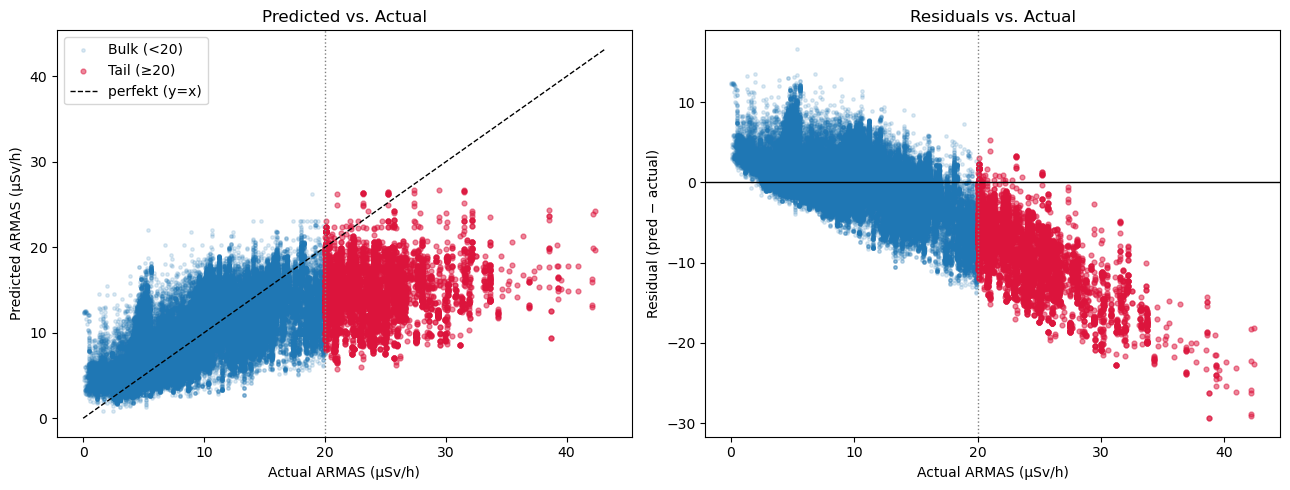

In [25]:
import matplotlib.pyplot as plt

is_tail = p["y_true"] >= TAIL
resid = p["y_pred"] - p["y_true"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(p.loc[~is_tail,"y_true"], p.loc[~is_tail,"y_pred"], s=6, alpha=0.15, label="Bulk (<20)")
ax.scatter(p.loc[is_tail,"y_true"],  p.loc[is_tail,"y_pred"],  s=12, alpha=0.5,
           color="crimson", label="Tail (≥20)")
hi = max(p["y_true"].max(), p["y_pred"].max()) * 1.02
ax.plot([0, hi], [0, hi], "k--", lw=1, label="perfekt (y=x)")
ax.axvline(TAIL, color="grey", ls=":", lw=1)
ax.set(xlabel="Actual ARMAS (µSv/h)", ylabel="Predicted ARMAS (µSv/h)", title="Predicted vs. Actual")
ax.legend(loc="upper left")

ax = axes[1]
ax.scatter(p.loc[~is_tail,"y_true"], resid[~is_tail], s=6, alpha=0.15)
ax.scatter(p.loc[is_tail,"y_true"],  resid[is_tail],  s=12, alpha=0.5, color="crimson")
ax.axhline(0, color="k", lw=1); ax.axvline(TAIL, color="grey", ls=":", lw=1)
ax.set(xlabel="Actual ARMAS (µSv/h)", ylabel="Residual (pred − actual)", title="Residuals vs. Actual")

plt.tight_layout()
plt.savefig("fig_xgb_baseline_errors.png", dpi=200, bbox_inches="tight")
plt.show()

In [32]:
from sklearn.metrics import precision_score, recall_score, f1_score

clf = []
for split, g in xgb_predictions_all.groupby("Split"):
    a = (g["y_true"] >= TAIL).astype(int)
    b = (g["y_pred"] >= TAIL).astype(int)
    clf.append({
        "Split": split,
        "Precision": precision_score(a, b, zero_division=0),
        "Recall":    recall_score(a, b, zero_division=0),
        "F1":        f1_score(a, b, zero_division=0),
        "FN": int(((a==1) & (b==0)).sum()),   # verpasste Tail-Events
        "TP": int(((a==1) & (b==1)).sum()),   # erkannte Tail-Events
    })
clf = pd.DataFrame(clf)
print(clf.round(3).to_string(index=False))
print("\nMean ± Std über 6 Splits:")
print(clf[["Precision","Recall","F1"]].agg(["mean","std"]).round(3))

Split  Precision  Recall    F1   FN  TP
  123      0.879   0.058 0.109 1413  87
  132      0.591   0.035 0.065 1455  52
  213      0.000   0.000 0.000 1500   0
  231      0.667   0.004 0.008 1426   6
  312      0.642   0.029 0.055 1464  43
  321      0.532   0.081 0.141 1316 116

Mean ± Std über 6 Splits:
      Precision  Recall     F1
mean      0.552   0.034  0.063
std       0.295   0.031  0.055


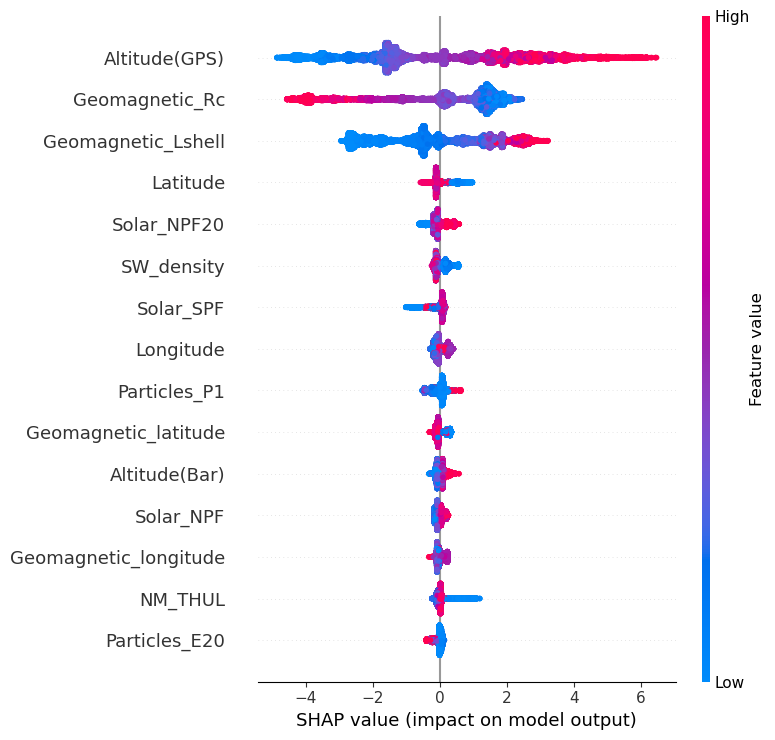

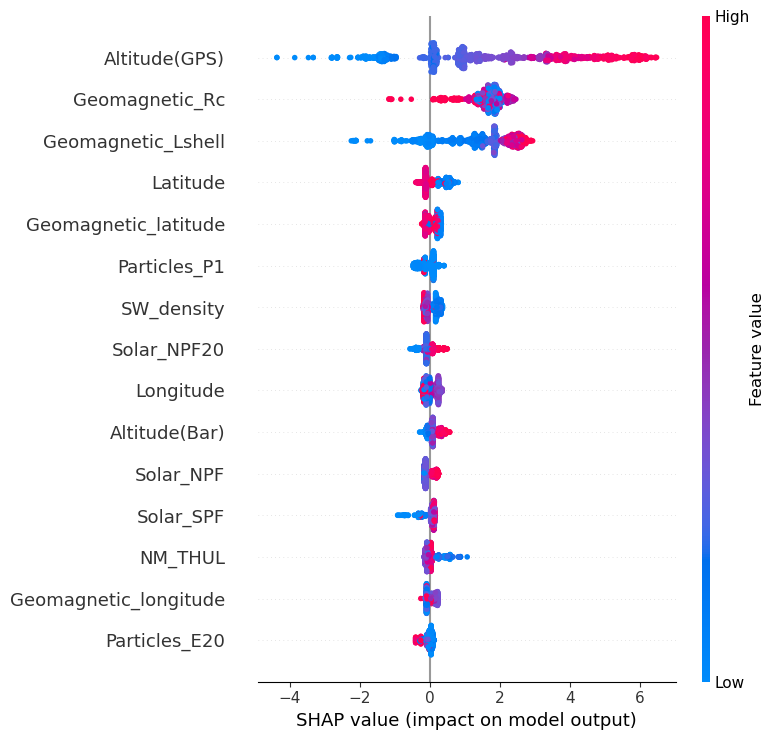

In [31]:
import shap
from xgboost import XGBRegressor

shap_split = "231"   # Sanjibs bester Split; beliebig wählbar
r = xgb_best_params_by_split.set_index("Split").loc[shap_split]
train_p, test_p = "P" + shap_split[0], "P" + shap_split[2]

X_train = df[df["partition"]==train_p][feature_cols]
y_train = df[df["partition"]==train_p][target_col]
X_test  = df[df["partition"]==test_p][feature_cols]
y_test  = df[df["partition"]==test_p][target_col]

params = {k: (int(r[k]) if k in ("n_estimators","max_depth") else float(r[k]))
          for k in ["n_estimators","max_depth","learning_rate","subsample",
                    "colsample_bytree","reg_alpha","reg_lambda"]}
model = XGBRegressor(**params, objective="reg:squarederror",
                     random_state=42, n_jobs=-1, tree_method="hist").fit(X_train, y_train)

expl = shap.TreeExplainer(model)
sv = expl.shap_values(X_test)

shap.summary_plot(sv, X_test, max_display=15, show=False)
plt.tight_layout(); plt.savefig("fig_xgb_baseline_shap.png", dpi=200, bbox_inches="tight"); plt.show()

# optional, inhaltlich wertvoll: was treibt das Modell SPEZIELL im Tail?
tail_idx = (y_test.to_numpy() >= TAIL)
if tail_idx.sum() > 0:
    shap.summary_plot(sv[tail_idx], X_test[tail_idx], max_display=15, show=False)
    plt.tight_layout(); plt.savefig("fig_xgb_baseline_shap_tail.png", dpi=200, bbox_inches="tight"); plt.show()

weighted xgboost

In [33]:
# continuous desnity-based weights, based on Yang et al. (2021), LDS-Style

# rare events -> higher weight, calculated per split and only on y train
# n bins: resolution of target distribution 
# sigma: smoothening over bins (label distribution smoothening)
# max ratio: caps ultra rare bins 

from scipy.ndimage import gaussian_filter1d

def compute_density_weights(y, n_bins=50, sigma=2.0, max_ratio=50.0):
    y = np.asarray(y, dtype=float)
    edges = np.linspace(y.min(), y.max() + 1e-9, n_bins + 1)
    idx = np.clip(np.digitize(y, edges) - 1, 0, n_bins - 1)

    counts = np.bincount(idx, minlength=n_bins).astype(float)
    smoothed = gaussian_filter1d(counts, sigma=sigma, mode="nearest")  # LDS
    smoothed = np.clip(smoothed, 1e-6, None)

    w = 1.0 / smoothed[idx]          # invers to smoothened desnity
    w = w / w.min()                  # min = 1
    w = np.clip(w, 1.0, max_ratio)   # cap ratio
    w = w * (len(w) / w.sum())       
    return w

In [34]:
TAIL_THR = 20.0   # threshold

def tail_rmse(y_true, y_pred, thr=TAIL_THR):
    m = np.asarray(y_true) >= thr
    if m.sum() == 0:
        return np.inf
    e = np.asarray(y_pred)[m] - np.asarray(y_true)[m]
    return np.sqrt(np.mean(e ** 2))

xgbw_results = []
xgbw_best_params_by_split = []
xgbw_predictions_all = []

for train_p, val_p, test_p in tqdm(splits, desc="Weighted rotations"):
    split_name = f"{train_p[-1]}{val_p[-1]}{test_p[-1]}"

    train_df = df[df["partition"] == train_p].copy()
    val_df   = df[df["partition"] == val_p].copy()
    test_df  = df[df["partition"] == test_p].copy()

    X_train, y_train = train_df[feature_cols], train_df[target_col]
    X_val,   y_val   = val_df[feature_cols],   val_df[target_col]
    X_test,  y_test  = test_df[feature_cols],  test_df[target_col]

    # log1p-Target, weights only from train
    y_train_log = np.log1p(y_train.values)
    w_train     = compute_density_weights(y_train.values)

    best_crit = np.inf            # tail-aware: minimize Tail-RMSE on Val
    best_model = best_params = None

    for values in tqdm(param_combinations, desc=f"Grid {split_name}", leave=False):
        params = dict(zip(param_names, values))
        model = XGBRegressor(**params, objective="reg:squarederror",
                             random_state=42, n_jobs=-1, tree_method="hist")
        model.fit(X_train, y_train_log, sample_weight=w_train)   # weighted mse on log-Skale

        y_val_pred = np.expm1(model.predict(X_val))              # back to µSv/h 
        crit = tail_rmse(y_val.values, y_val_pred)               # tail-aware

        if crit < best_crit:
            best_crit, best_model, best_params = crit, model, params

    # best Model of all sets, always turn back to µSv/h
    y_train_pred = np.expm1(best_model.predict(X_train))
    y_val_pred   = np.expm1(best_model.predict(X_val))
    y_test_pred  = np.expm1(best_model.predict(X_test))

    train_m = evaluate_regression(y_train.values, y_train_pred)
    val_m   = evaluate_regression(y_val.values,   y_val_pred)
    test_m  = evaluate_regression(y_test.values,  y_test_pred)

    xgbw_results.append({
        "Model": "XGBoost-Weighted", "Split": split_name,
        "Train_partition": train_p, "Validation_partition": val_p, "Test_partition": test_p,
        "Train_RMSE": train_m["RMSE"], "Train_R2": train_m["R2"],
        "Validation_RMSE": val_m["RMSE"], "Validation_R2": val_m["R2"],
        "Test_RMSE": test_m["RMSE"], "Test_MAE": test_m["MAE"], "Test_R2": test_m["R2"],
        "Test_Pearson_r": test_m["Pearson_r"], "Test_Bias": test_m["Bias"],
        "Test_Underestimation_%": test_m["Underestimation_%"],
        "Best_Validation_TailRMSE": best_crit,
    })
    xgbw_best_params_by_split.append({"Split": split_name, **best_params,
                                      "Best_Validation_TailRMSE": best_crit})

    # Prediction DF w same features as xgb_predictions_all
    pred_df = pd.DataFrame({
        "Model": "XGBoost-Weighted", "Split": split_name,
        "Train_partition": train_p, "Validation_partition": val_p, "Test_partition": test_p,
        "y_true": y_test.values, "y_pred": y_test_pred,
    })
    pred_df["residual"]   = pred_df["y_pred"] - pred_df["y_true"]
    pred_df["abs_error"]  = pred_df["residual"].abs()
    pred_df["sq_error"]   = pred_df["residual"] ** 2
    pred_df["underpred"]  = pred_df["y_pred"] < pred_df["y_true"]
    pred_df["tail_ge_15"] = pred_df["y_true"] >= 15
    pred_df["tail_ge_20"] = pred_df["y_true"] >= 20
    pred_df["pred_ge_15"] = pred_df["y_pred"] >= 15
    pred_df["pred_ge_20"] = pred_df["y_pred"] >= 20
    xgbw_predictions_all.append(pred_df)

    # save after each split
    pd.DataFrame(xgbw_results).to_csv("xgbw_results_progress.csv", index=False)
    pd.concat(xgbw_predictions_all, ignore_index=True).to_csv("xgbw_predictions_progress.csv", index=False)

Weighted rotations:   0%|          | 0/6 [00:00<?, ?it/s]

Grid 123:   0%|          | 0/972 [00:00<?, ?it/s]

Grid 132:   0%|          | 0/972 [00:00<?, ?it/s]

Grid 213:   0%|          | 0/972 [00:00<?, ?it/s]

Grid 231:   0%|          | 0/972 [00:00<?, ?it/s]

Grid 312:   0%|          | 0/972 [00:00<?, ?it/s]

Grid 321:   0%|          | 0/972 [00:00<?, ?it/s]

In [35]:
xgbw_results = pd.DataFrame(xgbw_results)
xgbw_best_params_by_split = pd.DataFrame(xgbw_best_params_by_split)
xgbw_predictions_all = pd.concat(xgbw_predictions_all, ignore_index=True)

xgbw_results.to_csv("xgbw_results_final.csv", index=False)
xgbw_best_params_by_split.to_csv("xgbw_best_params_final.csv", index=False)
xgbw_predictions_all.to_csv("xgbw_predictions_all.csv", index=False)

print("Rows:", len(xgbw_predictions_all), "(erwartet 2 ×", len(df), "=", 2*len(df), ")")
xgbw_results

Rows: 184952 (erwartet 2 × 92476 = 184952 )


,Model,Split,Train_partition,Validation_partition,Test_partition,Train_RMSE,Train_R2,Validation_RMSE,Validation_R2,Test_RMSE,Test_MAE,Test_R2,Test_Pearson_r,Test_Bias,Test_Underestimation_%,Best_Validation_TailRMSE
0,XGBoost-Weighted,123,P1,P2,P3,4.232123,0.365227,4.329047,0.358318,4.504252,3.360557,0.298224,0.683720,1.364100,33.266232,7.339648
1,XGBoost-Weighted,132,P1,P3,P2,4.231046,0.365550,4.501735,0.299008,4.329323,3.223070,0.358237,0.692336,1.347502,31.974535,6.709560
2,XGBoost-Weighted,213,P2,P1,P3,4.194220,0.397666,4.471055,0.291529,4.240697,3.246955,0.377947,0.718416,1.498436,31.287318,7.059992
3,XGBoost-Weighted,231,P2,P3,P1,4.073018,0.431975,4.217165,0.384831,4.341392,3.254794,0.332026,0.706636,1.393728,34.891909,6.336386
4,XGBoost-Weighted,312,P3,P1,P2,3.723304,0.520476,4.309872,0.341690,4.208241,3.084062,0.393632,0.703461,1.031423,37.330692,7.235638
5,XGBoost-Weighted,321,P3,P2,P1,3.747648,0.514185,4.124798,0.417440,4.213026,3.148814,0.370943,0.696880,0.993642,39.129092,7.180407


In [36]:
def regime_summary(pred_df, label):
    out = []
    for split, g in pred_df.groupby("Split"):
        for regime, sub in {"Overall": g,
                            "Tail(>=20)": g[g["y_true"] >= 20]}.items():
            m = regression_metrics_subset(sub)
            out.append({"Model": label, "Split": split, "Regime": regime, **m})
    return pd.DataFrame(out)

both = pd.concat([regime_summary(xgb_predictions_all,  "Baseline"),
                  regime_summary(xgbw_predictions_all, "Weighted")], ignore_index=True)

compare = (both.groupby(["Regime", "Model"], observed=True)[["RMSE","MAE","Bias","Underestimation_%"]]
           .agg(["mean","std"]).round(3))
compare

RMSE           MAE          Bias         \
                      mean    std   mean    std   mean    std   
Regime     Model                                                
Overall    Baseline  3.682  0.046  2.703  0.031 -0.091  0.074   
           Weighted  4.306  0.113  3.220  0.095  1.271  0.208   
Tail(>=20) Baseline  9.492  0.438  8.572  0.458 -8.546  0.446   
           Weighted  7.186  0.547  5.705  0.578 -5.501  0.598   

                    Underestimation_%         
                                 mean    std  
Regime     Model                              
Overall    Baseline            45.093  1.302  
           Weighted            34.647  3.088  
Tail(>=20) Baseline            98.887  1.032  
           Weighted            90.935  4.605

In [37]:
# Tail-Detection (Recall/Precision) — Weighted XGBoost

from sklearn.metrics import precision_score, recall_score, f1_score

TAIL_THR = 20.0

clf_weighted = []
for split, g in xgbw_predictions_all.groupby("Split"):
    a = (g["y_true"] >= TAIL_THR).astype(int)   # tatsächlich erhöht
    b = (g["y_pred"] >= TAIL_THR).astype(int)   # als erhöht vorhergesagt
    clf_weighted.append({
        "Split": split,
        "Precision": precision_score(a, b, zero_division=0),
        "Recall":    recall_score(a, b, zero_division=0),
        "F1":        f1_score(a, b, zero_division=0),
        "FN": int(((a == 1) & (b == 0)).sum()),   # verpasste Tail-Events
        "TP": int(((a == 1) & (b == 1)).sum()),   # erkannte Tail-Events
    })

clf_weighted = pd.DataFrame(clf_weighted)
print(clf_weighted.round(3).to_string(index=False))
print("\nWeighted — Mean ± Std über 6 Splits:")
print(clf_weighted[["Precision", "Recall", "F1"]].agg(["mean", "std"]).round(3))

Split  Precision  Recall    F1   FN  TP
  123      0.273   0.517 0.357  724 776
  132      0.257   0.340 0.293  994 513
  213      0.286   0.303 0.294 1045 455
  231      0.231   0.341 0.275  943 489
  312      0.259   0.247 0.253 1135 372
  321      0.288   0.286 0.287 1022 410

Weighted — Mean ± Std über 6 Splits:
      Precision  Recall     F1
mean      0.266   0.339  0.293
std       0.021   0.094  0.035


In [39]:
# Baseline vs. Weighted - Table Recall Comparison
def tail_clf_summary(pred_df, label, thr=20.0):
    rows = []
    for split, g in pred_df.groupby("Split"):
        a = (g["y_true"] >= thr).astype(int)
        b = (g["y_pred"] >= thr).astype(int)
        rows.append({"Model": label,
                     "Precision": precision_score(a, b, zero_division=0),
                     "Recall":    recall_score(a, b, zero_division=0),
                     "F1":        f1_score(a, b, zero_division=0)})
    return pd.DataFrame(rows)

clf_compare = pd.concat([
    tail_clf_summary(xgb_predictions_all,  "Baseline"),
    tail_clf_summary(xgbw_predictions_all, "Weighted"),
], ignore_index=True)

clf_compare.groupby("Model")[["Precision","Recall","F1"]].agg(["mean","std"]).round(3)

Precision        Recall            F1       
              mean    std   mean    std   mean    std
Model                                                
Baseline     0.552  0.295  0.034  0.031  0.063  0.055
Weighted     0.266  0.021  0.339  0.094  0.293  0.035

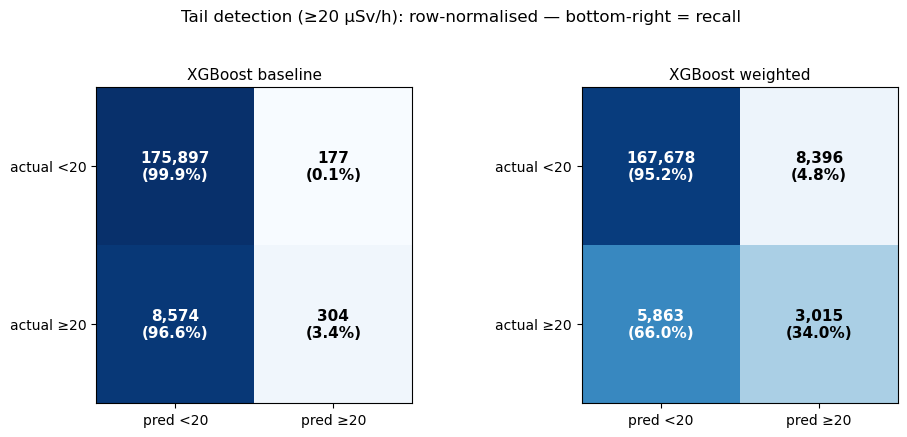

In [40]:
# Confusion Matrix: Baseline vs. Weighted 

import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

TAIL_THR = 20.0

def make_cm(pred_df, thr=TAIL_THR):
    a = (pred_df["y_true"] >= thr).astype(int)
    b = (pred_df["y_pred"] >= thr).astype(int)
    return confusion_matrix(a, b, labels=[0, 1])

panels = [("XGBoost baseline", make_cm(xgb_predictions_all)),
          ("XGBoost weighted", make_cm(xgbw_predictions_all))]

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, (title, cm) in zip(axes, panels):
    cmn = cm / cm.sum(axis=1, keepdims=True)            # zeilennormalisiert -> Recall-Sicht
    im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks([0, 1], ["pred <20", "pred ≥20"])
    ax.set_yticks([0, 1], ["actual <20", "actual ≥20"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}\n({cmn[i, j]:.1%})", ha="center", va="center",
                    fontsize=11, fontweight="bold",
                    color="white" if cmn[i, j] > 0.5 else "black")
    ax.set_title(title, fontsize=11)

fig.suptitle("Tail detection (≥20 µSv/h): row-normalised — bottom-right = recall",
             fontsize=12, y=1.03)
plt.tight_layout()
plt.savefig("fig_confusion_baseline_vs_weighted.pdf", bbox_inches="tight")
plt.show()

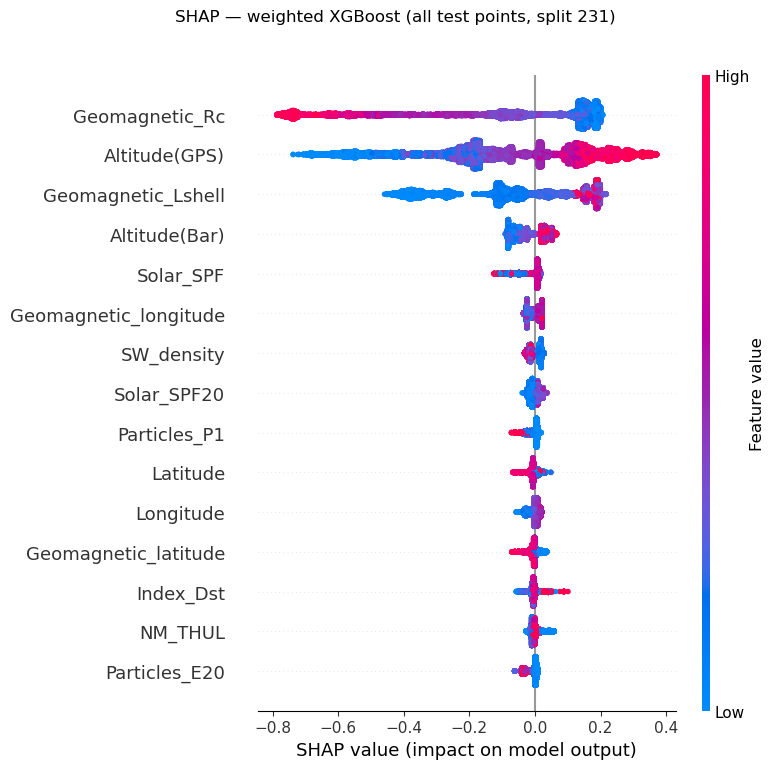

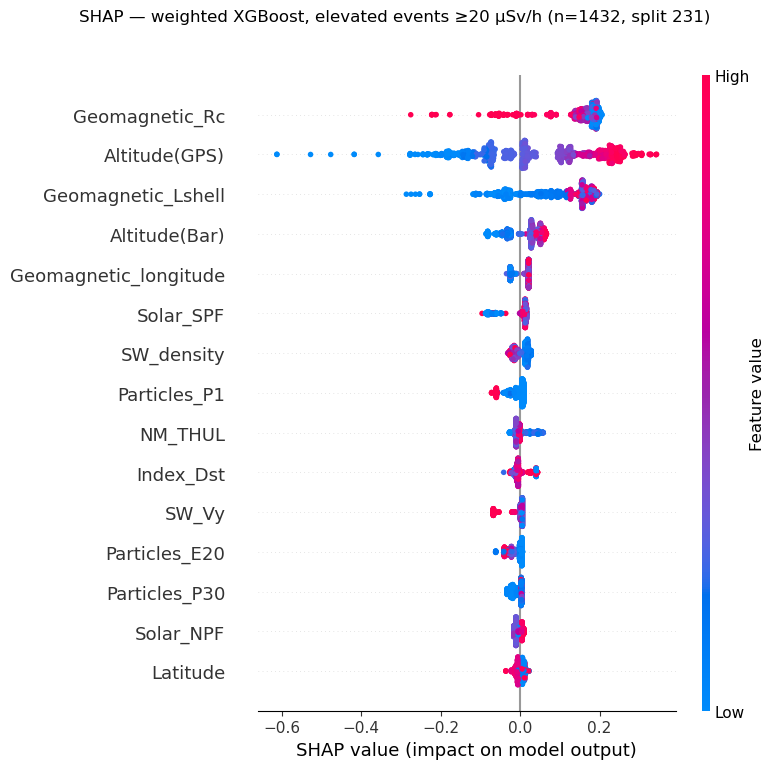

In [41]:
# SHAP: Weighted XGBoost 
import shap
from xgboost import XGBRegressor

TAIL_THR = 20.0
shap_split = "231"   # same split as baseline shap for fair comparison

r = xgbw_best_params_by_split.set_index("Split").loc[shap_split]
train_p, test_p = "P" + shap_split[0], "P" + shap_split[2]

X_train = df[df["partition"] == train_p][feature_cols]
y_train = df[df["partition"] == train_p][target_col]
X_test  = df[df["partition"] == test_p][feature_cols]
y_test  = df[df["partition"] == test_p][target_col]

# log1p-Target + densiyt based weights
y_train_log = np.log1p(y_train.values)
w_train     = compute_density_weights(y_train.values)

params = {k: (int(r[k]) if k in ("n_estimators", "max_depth") else float(r[k]))
          for k in ["n_estimators", "max_depth", "learning_rate", "subsample",
                    "colsample_bytree", "reg_alpha", "reg_lambda"]}
model_w = XGBRegressor(**params, objective="reg:squarederror",
                       random_state=42, n_jobs=-1, tree_method="hist")
model_w.fit(X_train, y_train_log, sample_weight=w_train)

expl = shap.TreeExplainer(model_w)
sv = expl.shap_values(X_test)

# global
shap.summary_plot(sv, X_test, max_display=15, show=False)
plt.gcf().suptitle(f"SHAP — weighted XGBoost (all test points, split {shap_split})",
                   fontsize=12, y=1.02)
plt.tight_layout(); plt.savefig("fig_xgbw_shap.pdf", bbox_inches="tight"); plt.show()

# only tail
tail_idx = (y_test.to_numpy() >= TAIL_THR)
if tail_idx.sum() > 0:
    shap.summary_plot(sv[tail_idx], X_test[tail_idx], max_display=15, show=False)
    plt.gcf().suptitle(f"SHAP — weighted XGBoost, elevated events ≥20 µSv/h "
                       f"(n={int(tail_idx.sum())}, split {shap_split})", fontsize=12, y=1.02)
    plt.tight_layout(); plt.savefig("fig_xgbw_shap_tail.pdf", bbox_inches="tight"); plt.show()

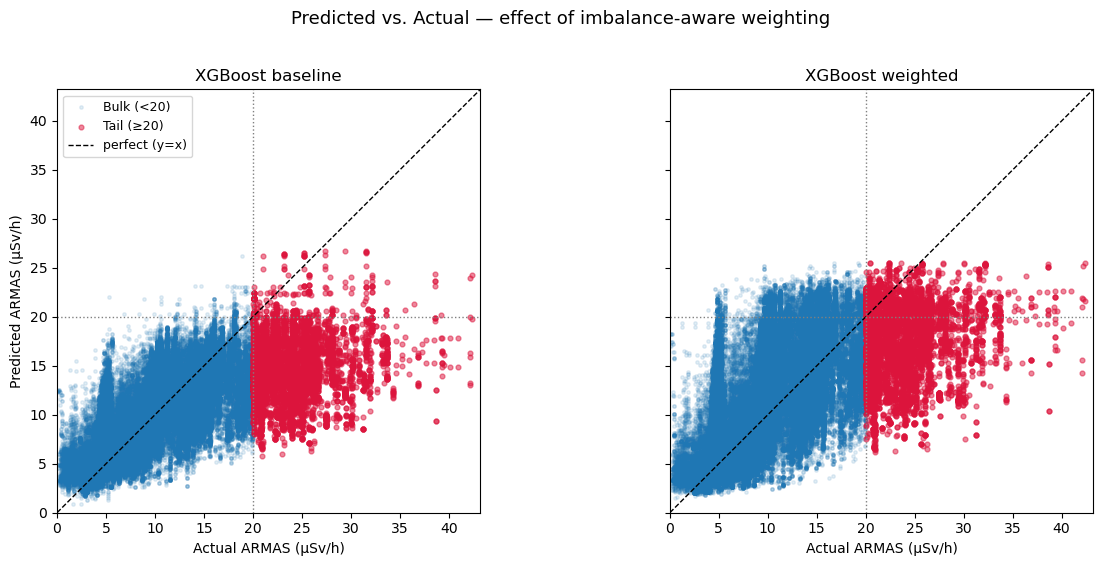

In [42]:
# error patterns: Predicted vs. Actual — Baseline vs. Weighted 

import numpy as np, matplotlib.pyplot as plt

TAIL_THR = 20.0
panels = [("XGBoost baseline", xgb_predictions_all),
          ("XGBoost weighted", xgbw_predictions_all)]

hi = max(xgb_predictions_all[["y_true","y_pred"]].max().max(),
         xgbw_predictions_all[["y_true","y_pred"]].max().max()) * 1.02

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)
for ax, (title, p) in zip(axes, panels):
    is_tail = p["y_true"] >= TAIL_THR
    ax.scatter(p.loc[~is_tail,"y_true"], p.loc[~is_tail,"y_pred"],
               s=6, alpha=0.12, label="Bulk (<20)")
    ax.scatter(p.loc[is_tail,"y_true"], p.loc[is_tail,"y_pred"],
               s=12, alpha=0.5, color="crimson", label="Tail (≥20)")
    ax.plot([0, hi], [0, hi], "k--", lw=1, label="perfect (y=x)")
    ax.axvline(TAIL_THR, color="grey", ls=":", lw=1)
    ax.axhline(TAIL_THR, color="grey", ls=":", lw=1)
    ax.set(xlim=(0, hi), ylim=(0, hi), xlabel="Actual ARMAS (µSv/h)", title=title)
    ax.set_aspect("equal", adjustable="box")
axes[0].set_ylabel("Predicted ARMAS (µSv/h)")
axes[0].legend(loc="upper left", fontsize=9)
fig.suptitle("Predicted vs. Actual — effect of imbalance-aware weighting", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("fig_pred_vs_actual_baseline_vs_weighted.pdf", bbox_inches="tight")
plt.show()